# Supplementary Analysis

## Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import scipy.stats as st

## Load / Prepare Data

In [10]:
# Read data
events = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/mouse_events_norm.csv")
hovers = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/mouse_hovers.csv")
df = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/participants.csv")
sub_metrics = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/submovement_metrics_norm.csv")

In [11]:
# Merge Condition to Events and Hovers
events = events.merge(df[["participant_id","interest"]], on="participant_id", how="inner")
hovers = hovers.merge(df[["participant_id","interest"]], on="participant_id", how="inner")

In [12]:
# Sort values in events and calculate velocity per event
events = events.sort_values(["participant_id","t_ms"])
events["dt_s"] = events.groupby("participant_id")["t_ms"].diff() / 1000.0
events["dx"]   = events.groupby("participant_id")["x_norm"].diff()
events["dy"]   = events.groupby("participant_id")["y_norm"].diff()
events["velocity_s"]= np.sqrt(events["dx"]**2 + events["dy"]**2) / np.clip(events["dt_s"], 1e-6, None)

## Mouse Visualizations by Interest

/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/319336126.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[::DOWNSAMPLE_STEP])
/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/319336126.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(N_PER_INTEREST, len(x)), random_state=RANDOM_STATE))["participant_id"]


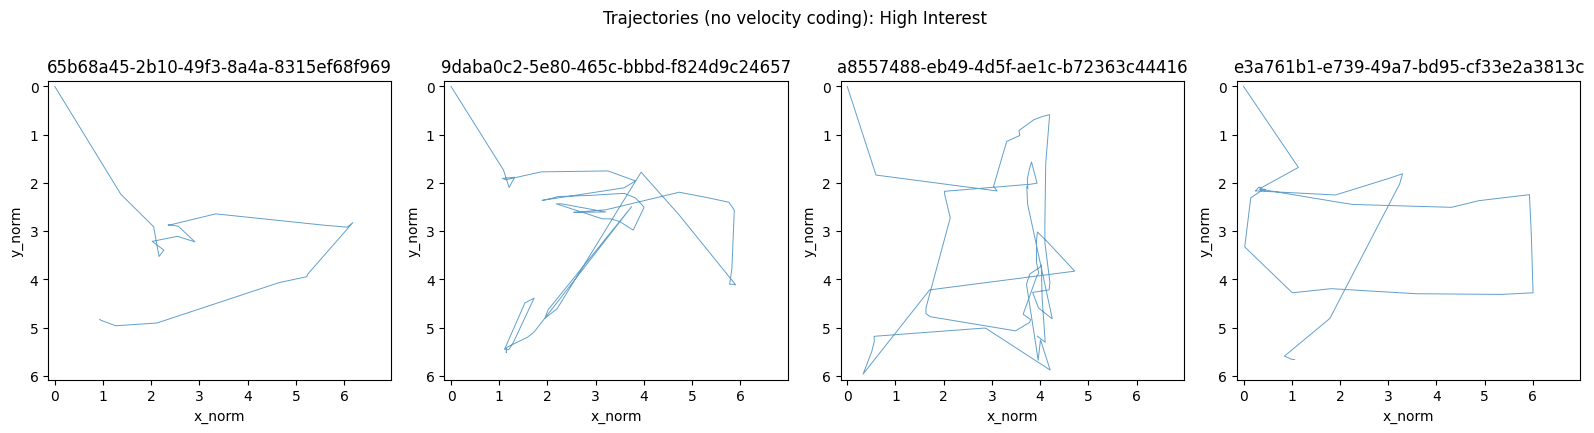

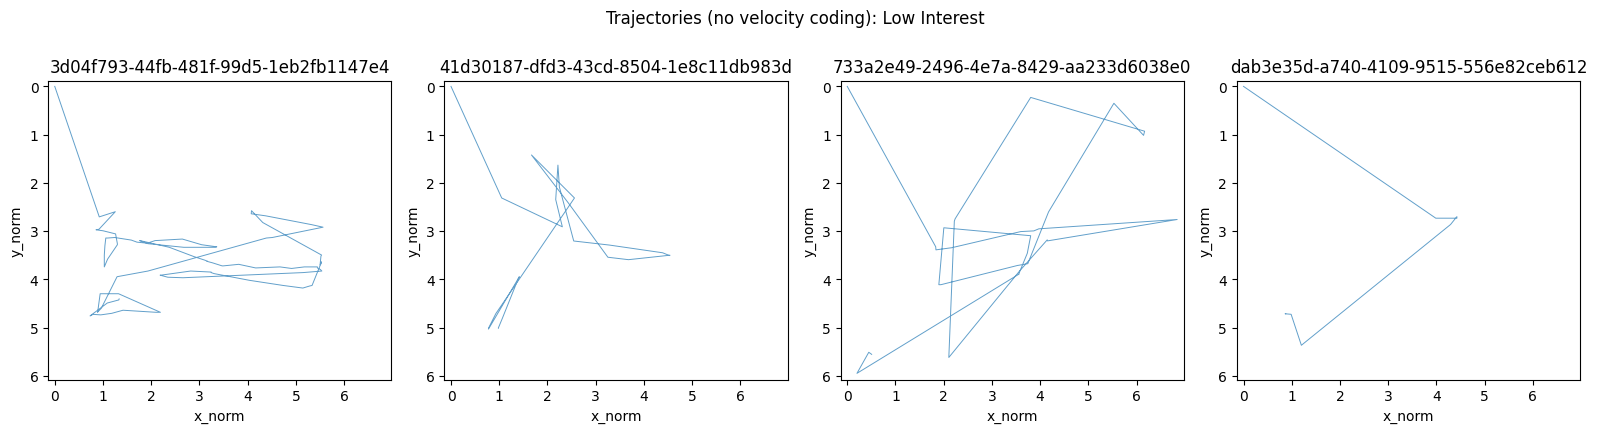

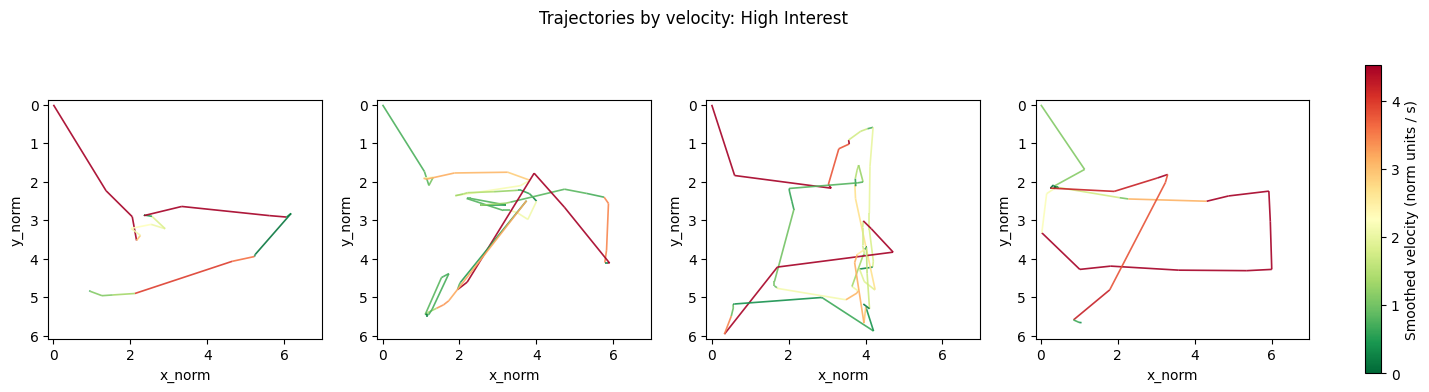

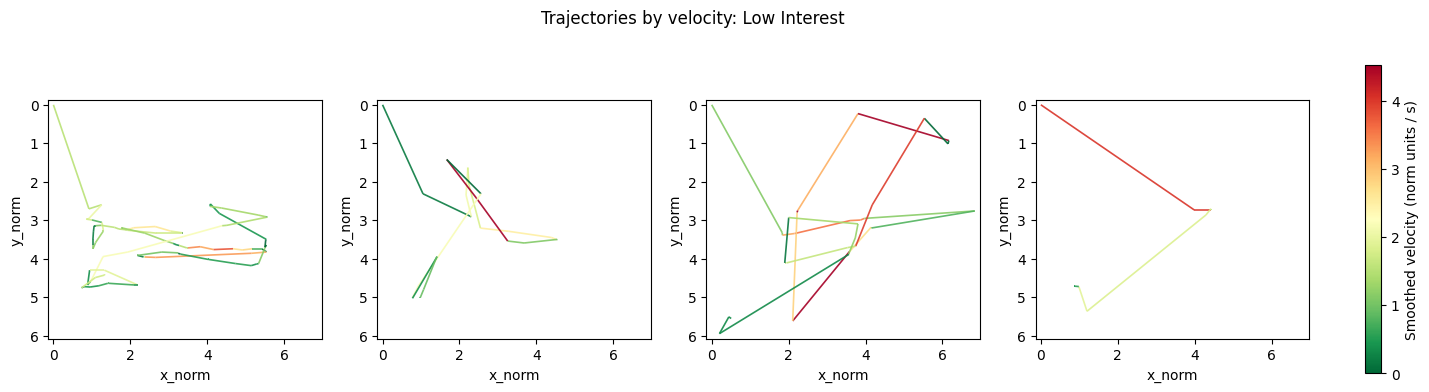

In [5]:
##################### Parameters #####################
# Sampling / General
N_PER_INTEREST   = 4
RANDOM_STATE     = 5  # 5
DOWNSAMPLE_STEP  = 5
SMOOTH_WIN       = 5
CMAP             = "RdYlGn_r"

##################### Cleaning / Downsampling #####################

# Keep only rows needed for plotting
events_plot = events.dropna(subset=["participant_id", "interest", "t_ms", "x_norm", "y_norm", "velocity_s"]).copy()

# Sort participants by time
events_plot = events_plot.sort_values(["participant_id", "t_ms"])

# Downsampling
if DOWNSAMPLE_STEP > 1:
    events_plot = (
        events_plot.groupby("participant_id", group_keys=False)
                   .apply(lambda g: g.iloc[::DOWNSAMPLE_STEP])
                   .reset_index(drop=True)
    )

##################### Sample Participants #####################

# Create a unique list of participants
tmp = events_plot[["participant_id", "interest"]].drop_duplicates()

# Sample up to N_PER_INTEREST participants
keep_ids = (
    tmp.groupby("interest", group_keys=False)
       .apply(lambda x: x.sample(n=min(N_PER_INTEREST, len(x)), random_state=RANDOM_STATE))["participant_id"]
       .tolist()
)

# Restrict plotting dataframe to sampled participants
events_plot = events_plot[events_plot["participant_id"].isin(keep_ids)].copy()
events_plot = events_plot.sort_values(["interest", "participant_id", "t_ms"])

##################### GLOBAL AXIS LIMITS (same for all subplots) #####################
# Compute limits over the actually plotted sample (robust + small padding)
x = events_plot["x_norm"].to_numpy(dtype="float64")
y = events_plot["y_norm"].to_numpy(dtype="float64")
ok = np.isfinite(x) & np.isfinite(y)

if np.any(ok):
    xmin, xmax = np.nanmin(x[ok]), np.nanmax(x[ok])
    ymin, ymax = np.nanmin(y[ok]), np.nanmax(y[ok])
else:
    xmin, xmax, ymin, ymax = 0.0, 1.0, 0.0, 1.0

pad = 0.02
xr = xmax - xmin
yr = ymax - ymin
if xr == 0: xr = 1e-6
if yr == 0: yr = 1e-6

xmin, xmax = xmin - pad * xr, xmax + pad * xr
ymin, ymax = ymin - pad * yr, ymax + pad * yr
# NOTE: y will be inverted via set_ylim(ymax, ymin)
#####################################################################################


##################### Plot Trajectories #####################

# For each interest group, plot one panel per sampled participant
for interest, g in events_plot.groupby("interest"):

    pids = g["participant_id"].drop_duplicates().tolist()

    # one subplot per participant
    fig, axes = plt.subplots(1, len(pids), figsize=(4 * len(pids), 4), sharex=False, sharey=False)
    if len(pids) == 1:
        axes = [axes]

    for ax, pid in zip(axes, pids):
        p = g[g["participant_id"] == pid].sort_values("t_ms")

        # Line
        ax.plot(p["x_norm"], p["y_norm"], alpha=0.7, linewidth=0.7)

        # SAME LIMITS ON EVERY SUBPLOT (and y inverted)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymax, ymin)

        # Equal Scaling on x/y
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x_norm")
        ax.set_ylabel("y_norm")
        ax.set_title(str(pid))

    fig.suptitle(f"Trajectories (no velocity coding): {interest} Interest", y=1.02)
    plt.tight_layout()
    plt.show()

##################### Moving Average Smoothing #####################

def smooth_moving_average(v, win=5):
    win = int(win)
    if win <= 1 or len(v) < win:
        return v
    k = np.ones(win) / win
    return np.convolve(v, k, mode="same")

##################### Coloring #####################

# Collect smoothed velocities from all selected participants
all_v = []
for pid, p in events_plot.groupby("participant_id"):
    p = p.sort_values("t_ms")

    # raw velocity values (per event)
    v_seg = p["velocity_s"].to_numpy(dtype="float64")

    # keep only finite values
    v_seg = v_seg[np.isfinite(v_seg)]
    if len(v_seg) == 0:
        continue

    # smooth velocities
    v_seg = smooth_moving_average(v_seg, win=SMOOTH_WIN)
    all_v.append(v_seg)

# Use robust limits to reduce outlier influence on the colormap
if all_v:
    all_v = np.concatenate(all_v)
    vmin, vmax = np.quantile(all_v, [0.01, 0.99])
else:
    vmin, vmax = 0.0, 1.0

norm = Normalize(vmin=vmin, vmax=vmax)

##################### Trajecotries with Velocity Color Coding #####################

for interest, g in events_plot.groupby("interest"):

    pids = g["participant_id"].drop_duplicates().tolist()
    n = len(pids)

    # Add an extra thin column for the colorbar
    fig = plt.figure(figsize=(4 * n + 1.2, 4))
    gs = GridSpec(1, n + 1, figure=fig, width_ratios=[1] * n + [0.06], wspace=0.25)

    axes = [fig.add_subplot(gs[0, i]) for i in range(n)]
    cax  = fig.add_subplot(gs[0, -1])

    for ax, pid in zip(axes, pids):
        p = g[g["participant_id"] == pid].sort_values("t_ms")

        x = p["x_norm"].to_numpy(dtype="float64")
        y = p["y_norm"].to_numpy(dtype="float64")
        v = p["velocity_s"].to_numpy(dtype="float64")

        # Keep only rows with finite coordinates
        ok = np.isfinite(x) & np.isfinite(y)
        x, y, v = x[ok], y[ok], v[ok]

        # Need at least 2 points to draw a segment
        if len(x) < 2:
            ax.set_title(f"PID {pid}\n(too few points)")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymax, ymin)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xlabel("x_norm")
            ax.set_ylabel("y_norm")
            continue

        # build line segments (n-1 segments)
        pts = np.column_stack([x, y]).reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

        # segment velocities (length n-1)
        v_seg = v[1:] if len(v) == len(x) else v[:len(segs)]
        v_seg = np.nan_to_num(
            v_seg,
            nan=np.nanmedian(v_seg) if np.any(np.isfinite(v_seg)) else 0.0
        )
        v_seg = smooth_moving_average(v_seg, win=SMOOTH_WIN)

        # colored segments
        lc = LineCollection(segs, cmap=CMAP, norm=norm)
        lc.set_array(v_seg[:len(segs)])
        lc.set_linewidth(1.2)
        lc.set_alpha(0.9)
        ax.add_collection(lc)

        # IMPORTANT: don't autoscale (that would change the "zoom" per subplot)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymax, ymin)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x_norm")
        ax.set_ylabel("y_norm")
        #ax.set_title(str(pid))

    # Add one shared colorbar per interest group
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=CMAP), cax=cax)
    cbar.set_label("Smoothed velocity (norm units / s)")

    fig.suptitle(f"Trajectories by velocity: {interest} Interest", y=1.02)
    plt.show()


## Direction Changes

In [6]:
##################### Parameters #####################
ANGLE_THRESHOLD_DEG = 45   # direction change if the turning angle exceeds this threshold
MIN_STEP_NORM = 0.002      # ignore tiny steps (mouse jitter) below this distance threshold
SMOOTH_WIN = 3             # smoothing window for x/y

##################### Centered moving average #####################

def smooth_series(a: np.ndarray, win: int) -> np.ndarray:
    win = int(win)
    if win <= 1 or len(a) < win:
        return a
    return (
        pd.Series(a, dtype="float64")
        .rolling(win, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

##################### Count direction changes ####################

def count_direction_changes(
    g: pd.DataFrame,
    x_col: str = "x_norm",
    y_col: str = "y_norm",
    t_col: str = "t_ms",
    angle_thresh_deg: float = 45,
    min_step: float = 0.002,
    smooth_win: int = 1
) -> int:

    # Coerce numeric + ensure clean time ordering
    g = g.copy()
    g[t_col] = pd.to_numeric(g[t_col], errors="coerce")
    g[x_col] = pd.to_numeric(g[x_col], errors="coerce")
    g[y_col] = pd.to_numeric(g[y_col], errors="coerce")

    # Remove missing values and sort by time
    g = g.dropna(subset=[x_col, y_col, t_col]).sort_values(t_col).reset_index(drop=True)
    if len(g) < 3:
        return 0

    # Extract positions
    x = g[x_col].to_numpy(dtype="float64")
    y = g[y_col].to_numpy(dtype="float64")

    # Optional smoothing to reduce noise
    x = smooth_series(x, smooth_win)
    y = smooth_series(y, smooth_win)

    # Step vectors between consecutive points
    dx = np.diff(x)
    dy = np.diff(y)

    # Step lengths
    step = np.sqrt(dx * dx + dy * dy)

    # Build v1 and v2 for each possible turning point (length = n-2)
    v1x, v1y = dx[:-1], dy[:-1]
    v2x, v2y = dx[1:],  dy[1:]

    # Only evaluate angles where both adjacent steps are big enough (avoid counting jitter)
    valid = (step[:-1] >= min_step) & (step[1:] >= min_step)
    if not np.any(valid):
        return 0

    # Compute angle using arccos( (v1·v2) / (|v1||v2|) )
    dot = v1x * v2x + v1y * v2y
    n1  = np.sqrt(v1x * v1x + v1y * v1y)
    n2  = np.sqrt(v2x * v2x + v2y * v2y)

    cosang = dot / np.clip(n1 * n2, 1e-12, None)
    cosang = np.clip(cosang, -1.0, 1.0)

    # Turning angle in degrees
    ang_deg = np.degrees(np.arccos(cosang))

    # Count large turns
    return int(np.sum((ang_deg > angle_thresh_deg) & valid))

##################### Calculation per Participant ####################

# Count direction changes per participant
direction_changes = (
    events.groupby("participant_id", dropna=False)
          .apply(lambda g: count_direction_changes(
              g,
              x_col="x_norm",
              y_col="y_norm",
              t_col="t_ms",
              angle_thresh_deg=ANGLE_THRESHOLD_DEG,
              min_step=MIN_STEP_NORM,
              smooth_win=SMOOTH_WIN
          ))
          .reset_index(name="n_direction_changes")
)

##################### Additional features ####################

# Duration
dur = (
    events.groupby("participant_id")["t_ms"]
          .agg(lambda s: (pd.to_numeric(s, errors="coerce").max() - pd.to_numeric(s, errors="coerce").min()) / 1000.0)
          .rename("trial_duration_s")
)

# Number of events
n_ev = events.groupby("participant_id").size().rename("n_events")

# Merge
direction_changes = (
    direction_changes
    .merge(dur, on="participant_id", how="left")
    .merge(n_ev, on="participant_id", how="left")
)

# Direction changes per second
direction_changes["dir_changes_per_s"] = direction_changes["n_direction_changes"] / direction_changes["trial_duration_s"]

print(direction_changes.head(20))


                          participant_id  n_direction_changes  \
0   01caf55c-3693-4aa3-bac2-862230173a5e                   23   
1   01f97700-9c92-4464-9bf8-21132acaa881                   11   
2   05bcca80-e838-4ef3-8ba8-39e870310e8f                    1   
3   09836b97-00f6-47f3-b9aa-c34ad5867121                   16   
4   0c8e7770-1c3e-40d4-af3e-561d63ec9aa3                   11   
5   10bcc14f-7fd9-4646-80bc-7eff4d2e1097                    7   
6   10e43c6b-430c-47be-8c7e-acfe0fe439b5                    9   
7   125fe34e-d1f0-498a-8fd0-5d0cf21e030d                   14   
8   15b9dd42-a1f4-43d2-a040-9bfa65d63082                   15   
9   1826a545-f6f3-47b9-a091-81477ba89250                    1   
10  21e9b22a-8b1c-4ce7-ab1e-b805e86aaf46                    3   
11  23242b4f-c591-42a9-98cd-e26b42ba18ad                   17   
12  241ca21f-0214-47fa-933c-b2c656f1819d                   27   
13  2a36f61f-3be1-4127-b878-3cc2adc0be75                    3   
14  2a788a65-9288-433d-8e

/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/108325300.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: count_direction_changes(


In [7]:
# save as CSV
direction_changes.to_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/direction_changes.csv", index=False)

## Pause Analysis

In [13]:
# Parameters 
pause_thresh_s = 0.2   # pause must last at least 200ms
eps = 1e-9             # speed threshold ~0

# Compute velocity
events = events.sort_values(["participant_id", "t_ms"]).copy()
events["dt_s"] = events.groupby("participant_id")["t_ms"].diff() / 1000.0
events["dx"]   = events.groupby("participant_id")["x_norm"].diff()
events["dy"]   = events.groupby("participant_id")["y_norm"].diff()
events["speed"] = np.sqrt(events["dx"]**2 + events["dy"]**2) / events["dt_s"].replace(0, np.nan)

# pause definition
events["is_pause"] = (events["speed"].fillna(0) <= eps)

# Find contiguous pause segments ("blocks") 
events["pause_block"] = events.groupby("participant_id")["is_pause"].apply(
    lambda s: (s != s.shift()).cumsum()
).reset_index(level=0, drop=True)

block = events.groupby(["participant_id","pause_block","is_pause"], as_index=False).agg(
    block_dur_s=("dt_s","sum")
)

pause_blocks = block[(block["is_pause"]) & (block["block_dur_s"] >= pause_thresh_s)].copy()

# Aggregate pause metrics per participant
pause_stats = pause_blocks.groupby("participant_id").agg(
    n_pauses=("block_dur_s","size"),
    total_pause_time_s=("block_dur_s","sum"),
    mean_pause_s=("block_dur_s","mean"),
    median_pause_s=("block_dur_s","median"),
    max_pause_s=("block_dur_s","max"),
).reset_index()

pause_stats = pause_stats.merge(
    sub_metrics[["participant_id", "trial_duration_s"]],
    on="participant_id",
    how="left"
)

pause_stats = pause_stats.merge(
    df[["participant_id", "interest", "load"]],
    on="participant_id",
    how="left"
).dropna(subset=["interest"])

pause_stats["pause_share"] = pause_stats["total_pause_time_s"] / pause_stats["trial_duration_s"]

# Summary by interest
print(pause_stats.head(10))


                         participant_id  n_pauses  total_pause_time_s  \
0  01caf55c-3693-4aa3-bac2-862230173a5e        74             165.104   
1  01f97700-9c92-4464-9bf8-21132acaa881        41              51.592   
2  05bcca80-e838-4ef3-8ba8-39e870310e8f        11              46.811   
3  09836b97-00f6-47f3-b9aa-c34ad5867121        46              25.486   
4  0c8e7770-1c3e-40d4-af3e-561d63ec9aa3        19              20.930   
5  10bcc14f-7fd9-4646-80bc-7eff4d2e1097        12               9.891   
6  10e43c6b-430c-47be-8c7e-acfe0fe439b5        17              16.843   
7  125fe34e-d1f0-498a-8fd0-5d0cf21e030d        25              54.402   
8  15b9dd42-a1f4-43d2-a040-9bfa65d63082        59              86.593   
9  1826a545-f6f3-47b9-a091-81477ba89250        19              43.235   

   mean_pause_s  median_pause_s  max_pause_s  trial_duration_s interest  load  \
0      2.231135           1.055       16.440           195.685      Low  High   
1      1.258341           0.532   

In [14]:
# Save velocity metrics to CSV
pause_analysis_path = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/pause_analysis.csv" 
pause_stats.to_csv(pause_analysis_path, index=False)

print(f"Saved analysis to: {pause_analysis_path}")

Saved analysis to: /Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/pause_analysis.csv


#### Visualize Pauses in the Trajectories


/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/812427344.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[::DOWNSAMPLE_STEP])
/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/812427344.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(N_PER_INTEREST, len(x)), random_state=RANDOM_STATE))["participant_id"]


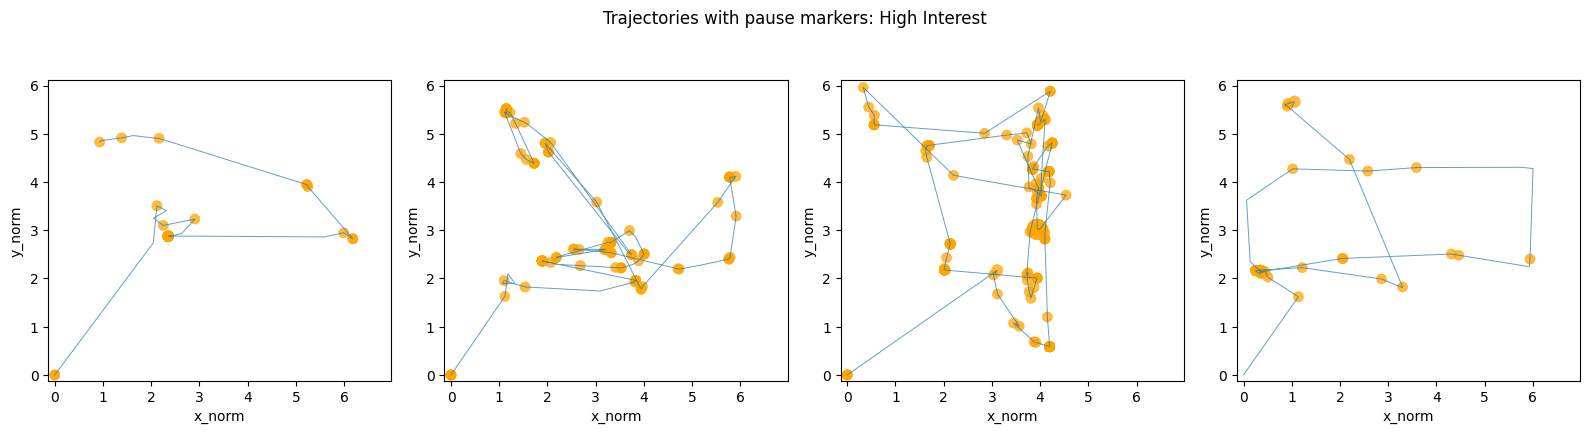

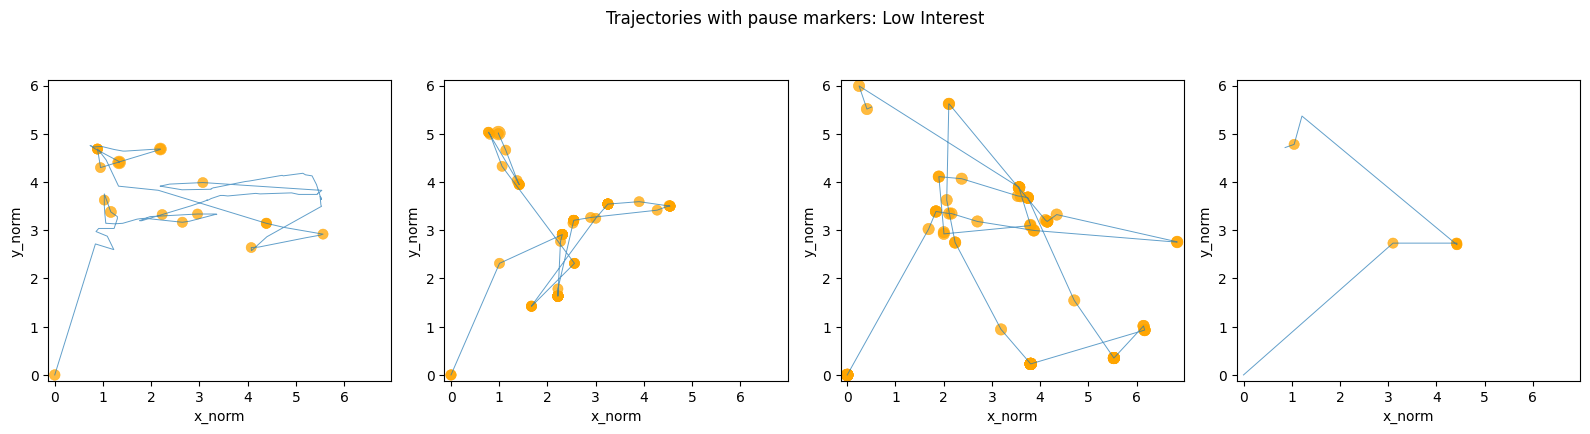

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##################### Parameters #####################
# Sampling / General
N_PER_INTEREST   = 4
RANDOM_STATE     = 5
DOWNSAMPLE_STEP  = 5

# Pause settings
PAUSE_THRESHOLD_S = 0.200   # pause if dt > 200ms
PAUSE_SIZE_MIN    = 20      # marker size for short pauses (area in points^2)
PAUSE_SIZE_MAX    = 220     # marker size for long pauses  (area in points^2)
PAUSE_SIZE_CAP_S  = 2.0     # pause durations above this are capped for sizing

# Pause marker styling
PAUSE_COLOR = "orange"
PAUSE_LW    = 0.4
PAUSE_EDGE  = None  # no edge

# Axis scaling
USE_GLOBAL_LIMITS = True   # same x/y limits across ALL plots
AXIS_PAD_FRAC     = 0.02   # small padding around limits


##################### Helper: Pause duration -> sizes (LOG scaling) #####################

# Map pause durations (seconds) to scatter marker sizes (area in points^2)
# Using log scaling to make small differences visible.
def pause_sizes_log(pause_dur, size_min, size_max, cap_s):
    pause_dur = np.asarray(pause_dur, dtype="float64")
    pdur = np.clip(pause_dur, 0.0, cap_s)
    scaled = np.log1p(pdur) / np.log1p(cap_s)   # in [0,1]
    sizes = size_min + (size_max - size_min) * scaled
    return sizes


##################### Cleaning / Downsampling #####################

events_plot = events.dropna(
    subset=["participant_id", "interest", "t_ms", "x_norm", "y_norm"]
).copy()

# Sort participants by time
events_plot = events_plot.sort_values(["participant_id", "t_ms"])

# Downsampling
if DOWNSAMPLE_STEP > 1:
    events_plot = (
        events_plot.groupby("participant_id", group_keys=False)
                   .apply(lambda g: g.iloc[::DOWNSAMPLE_STEP])
                   .reset_index(drop=True)
    )

# Compute time differences between consecutive samples (seconds)
events_plot["dt_s"] = events_plot.groupby("participant_id")["t_ms"].diff() / 1000.0

# Identify pauses
events_plot["is_pause"] = events_plot["dt_s"] > PAUSE_THRESHOLD_S


##################### Sample Participants #####################

tmp = events_plot[["participant_id", "interest"]].drop_duplicates()

keep_ids = (
    tmp.groupby("interest", group_keys=False)
       .apply(lambda x: x.sample(n=min(N_PER_INTEREST, len(x)), random_state=RANDOM_STATE))["participant_id"]
       .tolist()
)

events_plot = events_plot[events_plot["participant_id"].isin(keep_ids)].copy()
events_plot = events_plot.sort_values(["interest", "participant_id", "t_ms"])


##################### Compute fixed axis limits #####################

def padded_limits(xmin, xmax, ymin, ymax, pad_frac=0.02):
    xr = xmax - xmin
    yr = ymax - ymin
    if xr == 0: xr = 1e-6
    if yr == 0: yr = 1e-6
    xmin = xmin - pad_frac * xr
    xmax = xmax + pad_frac * xr
    ymin = ymin - pad_frac * yr
    ymax = ymax + pad_frac * yr
    return xmin, xmax, ymin, ymax

if USE_GLOBAL_LIMITS:
    xmin = float(events_plot["x_norm"].min())
    xmax = float(events_plot["x_norm"].max())
    ymin = float(events_plot["y_norm"].min())
    ymax = float(events_plot["y_norm"].max())
    xmin, xmax, ymin, ymax = padded_limits(xmin, xmax, ymin, ymax, AXIS_PAD_FRAC)


##################### Plot Trajectories and Pauses #####################

for interest, g in events_plot.groupby("interest"):

    pids = g["participant_id"].drop_duplicates().tolist()

    # If not using global limits, compute per-interest limits
    if not USE_GLOBAL_LIMITS:
        xmin_i = float(g["x_norm"].min())
        xmax_i = float(g["x_norm"].max())
        ymin_i = float(g["y_norm"].min())
        ymax_i = float(g["y_norm"].max())
        xmin_i, xmax_i, ymin_i, ymax_i = padded_limits(xmin_i, xmax_i, ymin_i, ymax_i, AXIS_PAD_FRAC)

    fig, axes = plt.subplots(1, len(pids), figsize=(4 * len(pids), 4), sharex=False, sharey=False)
    if len(pids) == 1:
        axes = [axes]

    for ax, pid in zip(axes, pids):
        p = g[g["participant_id"] == pid].sort_values("t_ms").copy()

        # Line trajectory
        ax.plot(p["x_norm"], p["y_norm"], alpha=0.7, linewidth=0.7)

        # Pause markers placed at the point before the pause
        pause_rows = p[p["is_pause"]].copy()
        if not pause_rows.empty:
            prev = p.shift(1).loc[pause_rows.index]
            pause_dur = pause_rows["dt_s"].to_numpy(dtype="float64")

            sizes = pause_sizes_log(pause_dur, PAUSE_SIZE_MIN, PAUSE_SIZE_MAX, PAUSE_SIZE_CAP_S)

            ax.scatter(
                prev["x_norm"], prev["y_norm"],
                s=sizes,
                alpha=0.75,
                color=PAUSE_COLOR,
                edgecolors=PAUSE_EDGE,
                linewidths=PAUSE_LW
            )

        # Fixed axis limits and equal scaling 
        if USE_GLOBAL_LIMITS:
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
        else:
            ax.set_xlim(xmin_i, xmax_i)
            ax.set_ylim(ymin_i, ymax_i)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x_norm")
        ax.set_ylabel("y_norm")
  

    fig.suptitle(f"Trajectories with pause markers: {interest} Interest", y=1.02)
    plt.tight_layout()
    plt.show()


## Velocity Phase Analysis

Reuse base velocity computation from mouse_metrics.ipynb for phase-specific exploratory analysis:

In [16]:
GROUPING = ("participant_id",)

# Velocity function
def compute_velocity_from_df(events: pd.DataFrame,
                             group_cols=GROUPING,
                             x_col: str = "x_norm",
                             y_col: str = "y_norm") -> tuple[pd.DataFrame, pd.DataFrame]:
    required = {"participant_id", "t_ms", x_col, y_col}
    missing = required - set(events.columns)
    if missing:
        raise ValueError(f"events is missing required columns: {missing}")

    # Copy
    df = events.copy()

    # Ensure numeric types
    df["t_ms"] = pd.to_numeric(df["t_ms"], errors="coerce")
    df[x_col]  = pd.to_numeric(df[x_col], errors="coerce")
    df[y_col]  = pd.to_numeric(df[y_col], errors="coerce")

    # Drop unusable rows
    df = df.dropna(subset=["participant_id", "t_ms", x_col, y_col])

    # Sort within groups by time
    sort_cols = list(group_cols) + ["t_ms"]
    df = df.sort_values(sort_cols)

    # Compute deltas per group
    def _deltas(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()
        g["dx"] = g[x_col].diff()
        g["dy"] = g[y_col].diff()
        g["dt_ms"] = g["t_ms"].diff()

        # Euclidean distance
        g["dist_norm"] = np.sqrt(g["dx"]**2 + g["dy"]**2)

        g["dt_s"] = g["dt_ms"] / 1000.0  # in seconds

        # guard against zero/negative/NaN intervals
        bad_dt = ~np.isfinite(g["dt_s"]) | (g["dt_s"] <= 0)
        g.loc[bad_dt, ["dt_s", "dist_norm", "dx", "dy"]] = np.nan

        # velocity per segment
        g["velocity_norm_s"] = g["dist_norm"] / g["dt_s"]
        return g

    df_steps = (
        df.groupby(list(group_cols), dropna=False, as_index=False, group_keys=False)
          .apply(_deltas)
    )

    # Keep only valid step rows for aggregation (the first in each group will be NaN)
    valid = df_steps.dropna(subset=["dist_norm", "dt_s", "velocity_norm_s"]).copy()


    if valid.empty:
        empty_cols = list(group_cols) + [
            "total_distance_norm", "max_velocity_norm_s", "min_velocity_norm_s",
            "mean_velocity_norm_s", "std_velocity_norm_s", "mean_abs_dx", "mean_abs_dy", "n_steps"
        ]
        metrics = pd.DataFrame(columns=empty_cols)
        return metrics, df_steps

    grouped = valid.groupby(list(group_cols), dropna=False)

    metrics = grouped.agg(
        total_distance_norm = ("dist_norm", "sum"),
        max_velocity_norm_s = ("velocity_norm_s", "max"),
        min_velocity_norm_s = ("velocity_norm_s", "min"),
        mean_velocity_norm_s = ("velocity_norm_s", "mean"),
        std_velocity_norm_s = ("velocity_norm_s", "std"),
        n_steps             = ("velocity_norm_s", "count"),
    ).reset_index()

    # For groups with only one valid step, std is NaN → set to 0.0
    metrics["std_velocity_norm_s"] = metrics["std_velocity_norm_s"].fillna(0.0)

    return metrics, df_steps

Phase Analysis:

In [17]:
# Phase Labels
PHASE_LABELS = ["early", "mid", "late"]

# Label Function
def add_phase_labels(events: pd.DataFrame) -> pd.DataFrame:
    e = events.copy()

    # Ensure t_ms is numeric
    e["t_ms"] = pd.to_numeric(e["t_ms"], errors="coerce")
    e = e.dropna(subset=["participant_id", "t_ms"])

    # Compute start/end timestamps per participant
    tw = (
        e.groupby("participant_id")["t_ms"]
         .agg(t_start_ms="min", t_end_ms="max")
         .reset_index()
    )

    # Avoid division by zero (ensure end > start)
    tw["t_end_ms"] = np.maximum(tw["t_end_ms"], tw["t_start_ms"] + 1)

    # Join timing window back to events
    e = e.merge(tw, on="participant_id", how="left")

    # Compute relative time in [0, 1]
    denom = (e["t_end_ms"] - e["t_start_ms"]).astype(float)
    e["t_rel"] = (e["t_ms"] - e["t_start_ms"]) / denom
    e["t_rel"] = e["t_rel"].clip(0, 1)

    # Assign early/mid/late by tertiles of relative time
    bins = [0.0, 1/3, 2/3, 1.0000001]
    e["phase"] = pd.cut(
        e["t_rel"],
        bins=bins,
        labels=PHASE_LABELS,
        include_lowest=True
    )

    # Make phase an ordered categorical (early < mid < late)
    e["phase"] = pd.Categorical(e["phase"], categories=PHASE_LABELS, ordered=True)

    return e


def compute_velocity_by_phase(events: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    # Add phase labels to each event (early/mid/late within participant)
    e = add_phase_labels(events)

    # Collect per-phase participant metrics and per-phase debug outputs
    out = []
    steps_dict = {}

    for ph in PHASE_LABELS:
        # Filter to one phase only
        e_ph = e.loc[e["phase"] == ph].copy()

        # Recompute velocity inside the phase (per participant)
        m_ph, steps_ph = compute_velocity_from_df(e_ph, group_cols=("participant_id",))

        # Tag metrics with the phase
        m_ph["phase"] = ph
        out.append(m_ph)

        # Store optional step-level outputs for debugging/plotting
        steps_dict[ph] = steps_ph

    # Stack all phases into one long dataframe
    long_df = pd.concat(out, ignore_index=True)
    long_df["phase"] = pd.Categorical(long_df["phase"], categories=PHASE_LABELS, ordered=True)

    return long_df, steps_dict

# Compute participant-level velocity metrics separately for early/mid/late
velocity_phase_long, velocity_steps_by_phase = compute_velocity_by_phase(events)

# Preview results
velocity_phase_long.head(10)


/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/1808955158.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_deltas)
/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/1808955158.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_deltas)
/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_1691/1808955158.py:50: DeprecationWarning: DataFrameGroupBy.app

,participant_id,total_distance_norm,max_velocity_norm_s,min_velocity_norm_s,mean_velocity_norm_s,std_velocity_norm_s,n_steps,phase
0,01caf55c-3693-4aa3-bac2-862230173a5e,41.482373,18.829099,0.0,0.627616,2.354703,1630,early
1,01f97700-9c92-4464-9bf8-21132acaa881,11.045483,46.165177,0.0,0.493806,2.885591,489,early
2,05bcca80-e838-4ef3-8ba8-39e870310e8f,6.590173,56.396576,0.0,0.385666,2.932986,428,early
3,09836b97-00f6-47f3-b9aa-c34ad5867121,2.837900,32.817600,0.0,0.177922,1.783859,345,early
4,0c8e7770-1c3e-40d4-af3e-561d63ec9aa3,18.734705,39.842705,0.0,1.738890,4.300317,265,early
5,10bcc14f-7fd9-4646-80bc-7eff4d2e1097,15.072483,37.212723,0.0,2.900754,6.012840,130,early
6,10e43c6b-430c-47be-8c7e-acfe0fe439b5,6.386057,40.205318,0.0,0.616418,2.982036,220,early
7,125fe34e-d1f0-498a-8fd0-5d0cf21e030d,10.668181,73.101650,0.0,0.506448,3.763365,557,early
8,15b9dd42-a1f4-43d2-a040-9bfa65d63082,8.398989,45.995980,0.0,0.235626,1.775374,872,early
9,1826a545-f6f3-47b9-a091-81477ba89250,0.000000,0.000000,0.0,0.000000,0.000000,421,early


In [18]:
# Save
OUT_PATH = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/velocity_by_phase.csv"

velocity_phase_long.to_csv(OUT_PATH, index=False)
print("Saved to:", OUT_PATH)

Saved to: /Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/velocity_by_phase.csv
